# Lab 1 - MNIST CNN: Gradient vs Cập nhật Parabol

Notebook này minh họa 2 cách cập nhật tham số cho mạng CNN trên MNIST:
1. Cách chuẩn dựa trên gradient (backpropagation + SGD).
2. Cách không dùng gradient, cập nhật theo phương pháp parabol (nội suy bậc 2 trên hướng tìm kiếm).


In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Thiet bi dang dung:", device)


Thiet bi dang dung: cpu


## Tải dữ liệu MNIST và tạo DataLoader
Cell này dùng toàn bộ tập train 60,000 mẫu cho cả hai phương pháp.
Dùng cùng batch size để so sánh công bằng.


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="data", train=False, download=True, transform=transform)

common_batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=common_batch_size, shuffle=True, num_workers=0)
parabola_loader = DataLoader(train_dataset, batch_size=common_batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

print(f"Kich thuoc train dung de so sanh: {len(train_dataset)}")
print(f"Batch size chung: {common_batch_size}")
print(f"Kich thuoc test: {len(test_dataset)}")


Kich thuoc train dung de so sanh: 60000
Batch size chung: 256
Kich thuoc test: 10000


## Xem nhanh một vài mẫu MNIST
Cell này hiển thị 8 ảnh đầu tiên của một mini-batch để kiểm tra dữ liệu đã được đọc đúng.


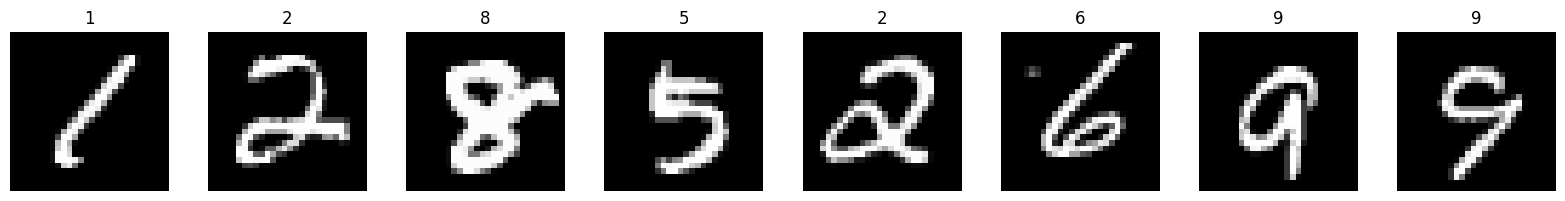

In [3]:
images, labels = next(iter(train_loader))
images = images[:8]
labels = labels[:8]

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze().numpy(), cmap="gray")
    ax.set_title(int(labels[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()


## Định nghĩa mô hình CNN
Mô hình gồm 2 khối convolution + pooling, sau đó là 2 lớp fully connected để phân loại 10 lớp chữ số.


In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


## Hàm huấn luyện và đánh giá cho cách gradient
Cell này gồm hàm loss cross-entropy tự cài đặt, hàm đánh giá, và hàm huấn luyện 1 epoch.
Phần gradient cập nhật tham số thủ công theo Gradient Descent cơ bản.


In [5]:
def cross_entropy_from_logits(logits, targets):
    # CE = mean(logsumexp(logits) - logits_true_class)
    logsumexp = torch.logsumexp(logits, dim=1)
    true_class_logits = logits.gather(1, targets.unsqueeze(1)).squeeze(1)
    return (logsumexp - true_class_logits).mean()


def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)

            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def manual_gradient_descent_step(model, lr):
    for p in model.parameters():
        if p.grad is not None:
            p -= lr * p.grad


def train_one_epoch_gradient(model, loader, loss_fn, lr):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        model.zero_grad(set_to_none=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        manual_gradient_descent_step(model, lr)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples


## Huấn luyện CNN bằng Gradient Descent cơ bản (tự cài đặt)
Cell này chạy huấn luyện gradient với quy tắc `theta <- theta - lr * grad`.
Không dùng optimizer có sẵn của PyTorch.


In [6]:
model_grad = SimpleCNN().to(device)
loss_fn = cross_entropy_from_logits
lr_grad = 0.01

history_grad = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
}

epochs_grad = 10
for epoch in range(1, epochs_grad + 1):
    train_loss, train_acc = train_one_epoch_gradient(model_grad, train_loader, loss_fn, lr_grad)
    test_loss, test_acc = evaluate(model_grad, test_loader, loss_fn)

    history_grad["train_loss"].append(train_loss)
    history_grad["train_acc"].append(train_acc)
    history_grad["test_loss"].append(test_loss)
    history_grad["test_acc"].append(test_acc)

    print(
        f"[Gradient] Epoch {epoch}/{epochs_grad} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
    )


[Gradient] Epoch 1/10 | train_loss=1.4444, train_acc=0.6486, test_loss=0.5163, test_acc=0.8570
[Gradient] Epoch 2/10 | train_loss=0.4153, train_acc=0.8781, test_loss=0.3970, test_acc=0.8760
[Gradient] Epoch 3/10 | train_loss=0.3114, train_acc=0.9074, test_loss=0.3037, test_acc=0.9093
[Gradient] Epoch 4/10 | train_loss=0.2608, train_acc=0.9228, test_loss=0.2282, test_acc=0.9322
[Gradient] Epoch 5/10 | train_loss=0.2214, train_acc=0.9351, test_loss=0.2308, test_acc=0.9300
[Gradient] Epoch 6/10 | train_loss=0.1907, train_acc=0.9439, test_loss=0.1730, test_acc=0.9469
[Gradient] Epoch 7/10 | train_loss=0.1659, train_acc=0.9508, test_loss=0.1557, test_acc=0.9548
[Gradient] Epoch 8/10 | train_loss=0.1462, train_acc=0.9567, test_loss=0.1472, test_acc=0.9518
[Gradient] Epoch 9/10 | train_loss=0.1309, train_acc=0.9619, test_loss=0.1152, test_acc=0.9653
[Gradient] Epoch 10/10 | train_loss=0.1183, train_acc=0.9658, test_loss=0.1124, test_acc=0.9674


## Hiển thị kết quả gradient
Cell này in accuracy cuối cùng và vẽ biểu đồ loss/accuracy theo epoch.


Độ chính xác test cuối cùng (gradient): 96.74%


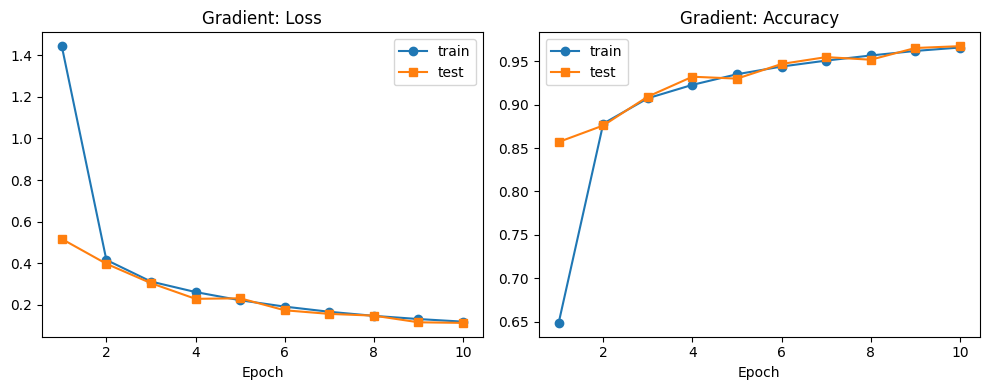

In [7]:
print(f"Độ chính xác test cuối cùng (gradient): {history_grad['test_acc'][-1] * 100:.2f}%")

epoch_axis = range(1, len(history_grad["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(epoch_axis, history_grad["train_loss"], marker="o", label="train")
axes[0].plot(epoch_axis, history_grad["test_loss"], marker="s", label="test")
axes[0].set_title("Gradient: Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epoch_axis, history_grad["train_acc"], marker="o", label="train")
axes[1].plot(epoch_axis, history_grad["test_acc"], marker="s", label="test")
axes[1].set_title("Gradient: Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## Định nghĩa cập nhật tham số bằng phương pháp parabol (không backward)
Mỗi mini-batch đánh giá loss tại `-delta`, `0`, `+delta` theo một hướng ngẫu nhiên.
Sau đó nội suy parabol để chọn `alpha*` và cập nhật `theta <- theta + alpha* d`.


In [8]:
def trainable_params(model):
    return [p for p in model.parameters() if p.requires_grad]


@torch.no_grad()
def set_params(params, base_params, direction, alpha):
    for p, b, d in zip(params, base_params, direction):
        p.copy_(b + alpha * d)


def normalize_direction(direction):
    sq_norm = torch.tensor(0.0, device=direction[0].device)
    for d in direction:
        sq_norm += (d * d).sum()
    norm = torch.sqrt(sq_norm).item()
    norm = max(norm, 1e-12)
    return [d / norm for d in direction]


def parabolic_alpha(loss_minus, loss_zero, loss_plus, delta, alpha_clip):
    denom = loss_minus - 2.0 * loss_zero + loss_plus

    if denom > 1e-12:
        alpha_star = delta * (loss_minus - loss_plus) / (2.0 * denom)
    else:
        candidates = [(-delta, loss_minus), (0.0, loss_zero), (delta, loss_plus)]
        alpha_star = min(candidates, key=lambda t: t[1])[0]

    alpha_star = float(np.clip(alpha_star, -alpha_clip, alpha_clip))
    return alpha_star


def train_one_epoch_parabola(model, loader, loss_fn, delta=0.02, alpha_clip=0.05, max_batches=None):
    model.train()
    params = trainable_params(model)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_idx, (x, y) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            base_params = [p.detach().clone() for p in params]
            direction = [torch.randn_like(p) for p in params]
            direction = normalize_direction(direction)

            set_params(params, base_params, direction, -delta)
            loss_minus = loss_fn(model(x), y).item()

            set_params(params, base_params, direction, 0.0)
            loss_zero = loss_fn(model(x), y).item()

            set_params(params, base_params, direction, +delta)
            loss_plus = loss_fn(model(x), y).item()

            alpha = parabolic_alpha(loss_minus, loss_zero, loss_plus, delta, alpha_clip)
            set_params(params, base_params, direction, alpha)

            logits = model(x)
            loss_after = loss_fn(logits, y)

        total_loss += loss_after.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples


## Huấn luyện CNN bằng phương pháp parabol
Cell này huấn luyện mô hình bằng phương pháp parabol trên full train 60,000 mẫu.
Phương pháp này thường chậm hơn do cần nhiều lần forward trong mỗi bước.


In [9]:
model_para = SimpleCNN().to(device)
loss_fn_para = cross_entropy_from_logits

history_para = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
}

epochs_para = 20
for epoch in range(1, epochs_para + 1):
    train_loss, train_acc = train_one_epoch_parabola(
        model_para,
        parabola_loader,
        loss_fn_para,
        delta=0.02,
        alpha_clip=0.05,
        max_batches=None,
    )
    test_loss, test_acc = evaluate(model_para, test_loader, loss_fn_para)

    history_para["train_loss"].append(train_loss)
    history_para["train_acc"].append(train_acc)
    history_para["test_loss"].append(test_loss)
    history_para["test_acc"].append(test_acc)

    print(
        f"[Parabola] Epoch {epoch}/{epochs_para} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
    )


[Parabola] Epoch 1/20 | train_loss=2.2996, train_acc=0.1663, test_loss=2.2955, test_acc=0.1909
[Parabola] Epoch 2/20 | train_loss=2.2923, train_acc=0.2094, test_loss=2.2880, test_acc=0.2379
[Parabola] Epoch 3/20 | train_loss=2.2848, train_acc=0.2396, test_loss=2.2807, test_acc=0.2517
[Parabola] Epoch 4/20 | train_loss=2.2787, train_acc=0.2509, test_loss=2.2750, test_acc=0.2656
[Parabola] Epoch 5/20 | train_loss=2.2723, train_acc=0.2635, test_loss=2.2680, test_acc=0.2762
[Parabola] Epoch 6/20 | train_loss=2.2663, train_acc=0.2744, test_loss=2.2616, test_acc=0.2853
[Parabola] Epoch 7/20 | train_loss=2.2597, train_acc=0.2799, test_loss=2.2546, test_acc=0.2864
[Parabola] Epoch 8/20 | train_loss=2.2520, train_acc=0.2934, test_loss=2.2465, test_acc=0.3022
[Parabola] Epoch 9/20 | train_loss=2.2444, train_acc=0.3156, test_loss=2.2387, test_acc=0.3339
[Parabola] Epoch 10/20 | train_loss=2.2370, train_acc=0.3386, test_loss=2.2304, test_acc=0.3393
[Parabola] Epoch 11/20 | train_loss=2.2285, train

## Hiển thị kết quả parabol
Cell này in accuracy cuối cùng và vẽ biểu đồ loss/accuracy theo epoch cho phương pháp parabol.


Độ chính xác test cuối cùng (parabol): 55.48%


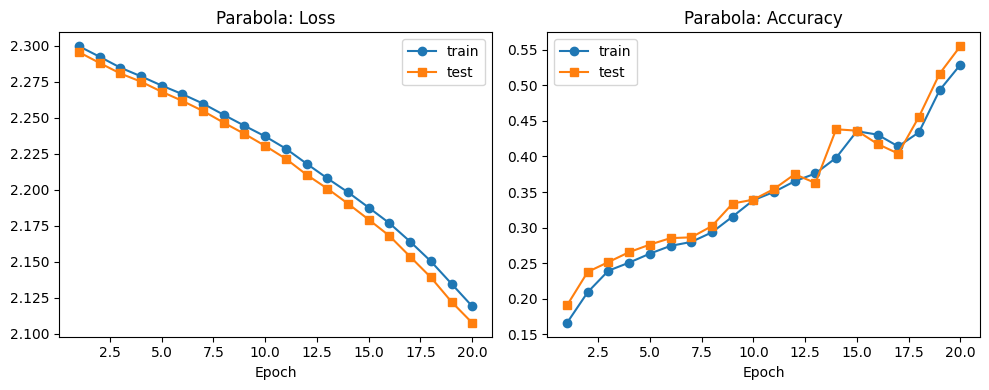

In [10]:
print(f"Độ chính xác test cuối cùng (parabol): {history_para['test_acc'][-1] * 100:.2f}%")

epoch_axis_para = range(1, len(history_para["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(epoch_axis_para, history_para["train_loss"], marker="o", label="train")
axes[0].plot(epoch_axis_para, history_para["test_loss"], marker="s", label="test")
axes[0].set_title("Parabola: Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epoch_axis_para, history_para["train_acc"], marker="o", label="train")
axes[1].plot(epoch_axis_para, history_para["test_acc"], marker="s", label="test")
axes[1].set_title("Parabola: Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## So sánh kết quả hai phương pháp
Cell này tạo bảng tổng hợp metric cuối cùng giữa gradient và parabol.


In [11]:
comparison = pd.DataFrame([
    {
        "Method": "Gradient",
        "Train samples/epoch": len(train_loader.dataset),
        "Epochs": epochs_grad,
        "Final test loss": history_grad["test_loss"][-1],
        "Final test acc (%)": history_grad["test_acc"][-1] * 100,
    },
    {
        "Method": "Parabol",
        "Train samples/epoch": len(parabola_loader.dataset),
        "Epochs": epochs_para,
        "Final test loss": history_para["test_loss"][-1],
        "Final test acc (%)": history_para["test_acc"][-1] * 100,
    },
])

comparison["Final test loss"] = comparison["Final test loss"].round(4)
comparison["Final test acc (%)"] = comparison["Final test acc (%)"].round(2)
comparison


,Method,Train samples/epoch,Epochs,Final test loss,Final test acc (%)
0,Gradient,60000,10,0.1124,96.74
1,Parabol,60000,20,2.1076,55.48


## Nhận xét
Cả hai phương pháp dùng cùng dữ liệu train full 60,000 mẫu và cùng batch size.
Gradient Descent thủ công thường hội tụ nhanh và chính xác hơn.
Parabol không dùng đạo hàm nhưng tốn nhiều lần forward nên chạy chậm hơn.
